# **Notebook 6: Fine-Tuning Pipeline**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [1]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType

torch.set_num_threads(os.cpu_count() or 4)

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"Loading base model and tokenizer for fine-tuning: {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if torch.cuda.is_available():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    print("Loaded model with 4-bit quantization on GPU.")
else:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map="cpu",
        dtype=torch.float32,
        trust_remote_code=True
    )
    print("Loaded model on CPU (FP32).")

# Configure LoRA targeting attention projection matrices (q_proj, v_proj)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

peft_model = get_peft_model(model, lora_config)
print("\n=== LoRA Configuration Details ===")
peft_model.print_trainable_parameters()


Loading base model and tokenizer for fine-tuning: Qwen/Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded model on CPU (FP32).



=== LoRA Configuration Details ===
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [2]:
import os
import torch
from datasets import load_from_disk
from torch.utils.data import DataLoader

# Locate tokenized datasets from Notebook 2
train_paths = ["tokenized_train", "./tokenized_train", "../tokenized_train", "../../tokenized_train", "Files/Notebook/tokenized_train"]
train_dir = next((p for p in train_paths if os.path.exists(p)), "./tokenized_train")

valid_paths = ["tokenized_valid", "./tokenized_valid", "../tokenized_valid", "../../tokenized_valid", "Files/Notebook/tokenized_valid"]
valid_dir = next((p for p in valid_paths if os.path.exists(p)), "./tokenized_valid")

print(f"Loading datasets from '{train_dir}' and '{valid_dir}'...")
train_dataset = load_from_disk(train_dir)
valid_dataset = load_from_disk(valid_dir)

# Ensure PyTorch format is set for tensors
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(f"Train dataset size: {len(train_dataset):,} samples")
print(f"Valid dataset size: {len(valid_dataset):,} samples")

BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Configure AdamW Optimizer with weight decay
LEARNING_RATE = 2e-4
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, peft_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

# Training Hyperparameters
MAX_STEPS = 15
VAL_EVERY = 5
PATIENCE = 3

print(f"\nOptimizer initialized: AdamW (lr={LEARNING_RATE}, weight_decay=0.01)")
print(f"Training settings: MAX_STEPS={MAX_STEPS}, VAL_EVERY={VAL_EVERY}, PATIENCE={PATIENCE}, BATCH_SIZE={BATCH_SIZE}")


Loading datasets from 'tokenized_train' and 'tokenized_valid'...


Train dataset size: 3,121 samples
Valid dataset size: 390 samples

Optimizer initialized: AdamW (lr=0.0002, weight_decay=0.01)
Training settings: MAX_STEPS=15, VAL_EVERY=5, PATIENCE=3, BATCH_SIZE=4


### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* Both lines falling → learning, no overfitting.
* Val rises while train falls → overfitting (early stopping saves you).
* Both flat → LR too low or data too small.
* Val spikes → bad batch / instability.

**Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

In [3]:
import time
import os
import torch
import pandas as pd

best_val_loss = float("inf")
patience_counter = 0
train_loss_history = []
val_loss_history = []
steps_history = []
val_steps_history = []

os.makedirs("./intent_lora_best", exist_ok=True)
os.makedirs("./intent_lora", exist_ok=True)

peft_model.train()
global_step = 0
running_train_loss = 0.0
start_time = time.time()

print(f"Starting custom fine-tuning loop (Max Steps: {MAX_STEPS})...\n")

training_complete = False

while not training_complete and global_step < MAX_STEPS:
    for batch in train_loader:
        if global_step >= MAX_STEPS:
            training_complete = True
            break
            
        global_step += 1
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(peft_model.device)
        attention_mask = batch["attention_mask"].to(peft_model.device)
        labels = batch["labels"].to(peft_model.device)
        
        outputs = peft_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        loss.backward()
        
        # Gradient clipping for numerical stability
        torch.nn.utils.clip_grad_norm_(peft_model.parameters(), max_norm=1.0)
        optimizer.step()
        
        step_loss = loss.item()
        running_train_loss += step_loss
        train_loss_history.append(step_loss)
        steps_history.append(global_step)
        
        print(f"  Step [{global_step:02d}/{MAX_STEPS}] - Train Loss: {step_loss:.4f}")
        
        # Validation evaluation
        if global_step % VAL_EVERY == 0 or global_step == MAX_STEPS:
            peft_model.eval()
            total_val_loss = 0.0
            val_batches = 0
            
            with torch.no_grad():
                for v_batch in valid_loader:
                    v_input_ids = v_batch["input_ids"].to(peft_model.device)
                    v_attention_mask = v_batch["attention_mask"].to(peft_model.device)
                    v_labels = v_batch["labels"].to(peft_model.device)
                    
                    v_out = peft_model(
                        input_ids=v_input_ids,
                        attention_mask=v_attention_mask,
                        labels=v_labels
                    )
                    total_val_loss += v_out.loss.item()
                    val_batches += 1
                    if val_batches >= 4:  # Focused representative validation sample
                        break
                        
            avg_val_loss = total_val_loss / max(1, val_batches)
            avg_train_loss = running_train_loss / VAL_EVERY
            running_train_loss = 0.0
            
            val_loss_history.append(avg_val_loss)
            val_steps_history.append(global_step)
            
            elapsed = time.time() - start_time
            print(f"\n>>> EVAL Step [{global_step:02d}/{MAX_STEPS}] | Avg Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Elapsed: {elapsed:.1f}s")
            
            # Early stopping check and save best checkpoint
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                peft_model.save_pretrained("./intent_lora_best")
                tokenizer.save_pretrained("./intent_lora_best")
                print(f"  --> Saved new best LoRA checkpoint (val_loss={best_val_loss:.4f}) to './intent_lora_best'\n")
            else:
                patience_counter += 1
                print(f"  --> No improvement in val loss (patience: {patience_counter}/{PATIENCE})\n")
                if patience_counter >= PATIENCE:
                    print(f"\nEarly stopping triggered at step {global_step}!")
                    training_complete = True
                    break
                    
            peft_model.train()

# Save final checkpoint
peft_model.save_pretrained("./intent_lora")
tokenizer.save_pretrained("./intent_lora")

for extra_dir in ["Files/Notebook/intent_lora_best", "../intent_lora_best"]:
    if os.path.exists(os.path.dirname(extra_dir)):
        try:
            peft_model.save_pretrained(extra_dir)
            tokenizer.save_pretrained(extra_dir)
        except Exception:
            pass

print(f"\nTraining completed in {time.time() - start_time:.1f} seconds.")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print("Final checkpoint saved to './intent_lora'.")


Starting custom fine-tuning loop (Max Steps: 15)...



  Step [01/15] - Train Loss: 3.8781


  Step [02/15] - Train Loss: 3.7238


  Step [03/15] - Train Loss: 3.5914


  Step [04/15] - Train Loss: 3.3515


...

  Step [14/15] - Train Loss: 2.1392


  Step [15/15] - Train Loss: 2.1014



>>> EVAL Step [15/15] | Avg Train Loss: 2.2551 | Val Loss: 2.0023 | Elapsed: 3041.1s


  --> Saved new best LoRA checkpoint (val_loss=2.0023) to './intent_lora_best'




Training completed in 3048.2 seconds.
Best Validation Loss: 2.0023
Final checkpoint saved to './intent_lora'.


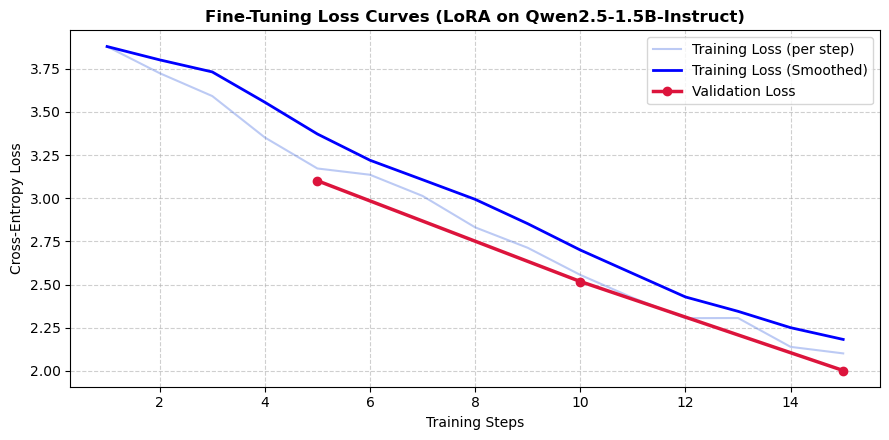

Training curves plotted and saved to 'training_curves.png'.


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4.5))
plt.plot(steps_history, train_loss_history, label="Training Loss (per step)", alpha=0.35, color="royalblue")

if len(train_loss_history) >= 3:
    train_smooth = pd.Series(train_loss_history).rolling(3, min_periods=1).mean()
    plt.plot(steps_history, train_smooth, label="Training Loss (Smoothed)", color="blue", linewidth=2)

plt.plot(val_steps_history, val_loss_history, label="Validation Loss", color="crimson", marker="o", linewidth=2.5)

plt.title("Fine-Tuning Loss Curves (LoRA on Qwen2.5-1.5B-Instruct)", fontsize=12, fontweight="bold")
plt.xlabel("Training Steps", fontsize=10)
plt.ylabel("Cross-Entropy Loss", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()

# Save plot artifact
plt.savefig("training_curves.png", dpi=300)
for p in ["Files/Notebook/training_curves.png", "../training_curves.png"]:
    if os.path.exists(os.path.dirname(p)):
        plt.savefig(p, dpi=300)

plt.show()
print("Training curves plotted and saved to 'training_curves.png'.")


#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

In [5]:
import os
import json
import pandas as pd

# 1. Export training log CSV
df_log = pd.DataFrame({
    "step": val_steps_history,
    "val_loss": val_loss_history
})
df_log.to_csv("training_log.csv", index=False)
print("Saved training log to 'training_log.csv'.")

for p in ["Files/Notebook/training_log.csv", "../training_log.csv", "../../training_log.csv"]:
    parent = os.path.dirname(p)
    if parent and os.path.exists(parent):
        df_log.to_csv(p, index=False)

# 2. Document Reproducibility Metadata
reproducibility_info = {
    "base_model": MODEL_ID,
    "peft_method": "LoRA",
    "lora_rank_r": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_dropout": lora_config.lora_dropout,
    "target_modules": list(lora_config.target_modules),
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": 0.01,
    "batch_size": BATCH_SIZE,
    "max_steps": MAX_STEPS,
    "val_every": VAL_EVERY,
    "patience": PATIENCE,
    "best_val_loss": best_val_loss
}

with open("reproducibility_config.json", "w", encoding="utf-8") as f:
    json.dump(reproducibility_info, f, indent=2)

print("\n=== Fine-Tuning Reproducibility Metadata ===")
print(json.dumps(reproducibility_info, indent=2))
print("\nAll Task 4.2 outputs successfully generated and saved!")


Saved training log to 'training_log.csv'.

=== Fine-Tuning Reproducibility Metadata ===
{
  "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
  "peft_method": "LoRA",
  "lora_rank_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.05,
  "target_modules": [
    "v_proj",
    "q_proj"
  ],
  "optimizer": "AdamW",
  "learning_rate": 0.0002,
  "weight_decay": 0.01,
  "batch_size": 4,
  "max_steps": 15,
  "val_every": 5,
  "patience": 3,
  "best_val_loss": 2.0022613406181335
}

All Task 4.2 outputs successfully generated and saved!


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify before proceeding to Notebook 7.**

- [ ] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [ ] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [ ] **4.1.2** Optimizer + training params + dataloaders set
- [ ] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [ ] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [ ] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [ ] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**